In [2]:
!wget -q -O chest_xray.zip \
"https://www.kaggle.com/api/v1/datasets/download/paultimothymooney/chest-xray-pneumonia"

In [3]:
import os

print("File exists:", os.path.exists("chest_xray.zip"))
print("Size:", os.path.getsize("chest_xray.zip") / (1024*1024), "MB")

File exists: True
Size: 2349.2483472824097 MB


In [4]:
import zipfile

with zipfile.ZipFile("chest_xray.zip", "r") as zip_ref:
    zip_ref.extractall("chest_xray_data")

print("Extracted successfully!")

Extracted successfully!


In [5]:
import os

print(os.listdir("chest_xray_data"))

['chest_xray']


In [6]:
print(os.listdir("chest_xray_data/chest_xray"))

['chest_xray', 'test', '__MACOSX', 'train', 'val']


In [7]:
from PIL import Image
import glob

data_path = "chest_xray_data/chest_xray"

images = glob.glob(data_path + "/train/*/*.jpeg")

print("Training images:", len(images))

img = Image.open(images[0])

print("Image size:", img.size)
print("Image mode:", img.mode)

Training images: 5216
Image size: (1742, 1684)
Image mode: L


NORMAL : 1341
PNEUMONIA : 3875


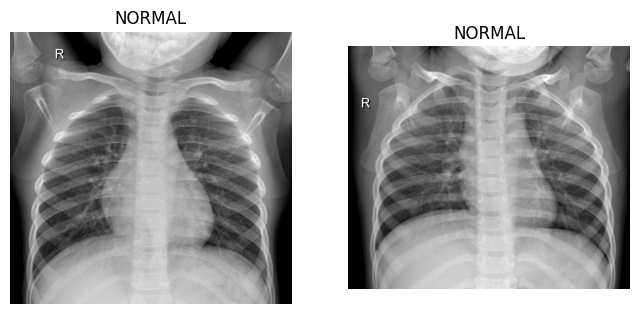

In [8]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

for cls in ["NORMAL", "PNEUMONIA"]:
    path = f"{data_path}/train/{cls}"
    print(cls, ":", len(os.listdir(path)))

images = glob.glob(f"{data_path}/train/*/*.jpeg")

plt.figure(figsize=(8,4))

for i, path in enumerate(images[:2]):
    img = Image.open(path)
    plt.subplot(1,2,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(os.path.basename(os.path.dirname(path)))
    plt.axis("off")

plt.show()

In [9]:
import numpy as np

IMG_SIZE = (224, 224)

img = Image.open(images[0]).convert("L")
img = img.resize(IMG_SIZE)

img_array = np.array(img, dtype=np.float32) / 255.0

print("Original size:", Image.open(images[0]).size)
print("Processed shape:", img_array.shape)
print("Pixel range:", img_array.min(), "to", img_array.max())

Original size: (1742, 1684)
Processed shape: (224, 224)
Pixel range: 0.0 to 0.96862745


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

generator = datagen.flow_from_directory(
    f"{data_path}/train",
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    batch_size=32
)

print("Class mapping:", generator.class_indices)
print("Batch shape:", generator[0][0].shape)

Found 5216 images belonging to 2 classes.
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Batch shape: (32, 224, 224, 1)


In [11]:
print("Mean pixel intensity:", img_array.mean())
print("Standard deviation:", img_array.std())

Mean pixel intensity: 0.4959281
Standard deviation: 0.22704852


In [13]:
Image.fromarray((img_array * 255).astype("uint8")).save(
    "processed_xray.png"
)

print("Processed X-ray saved successfully.")

Processed X-ray saved successfully.


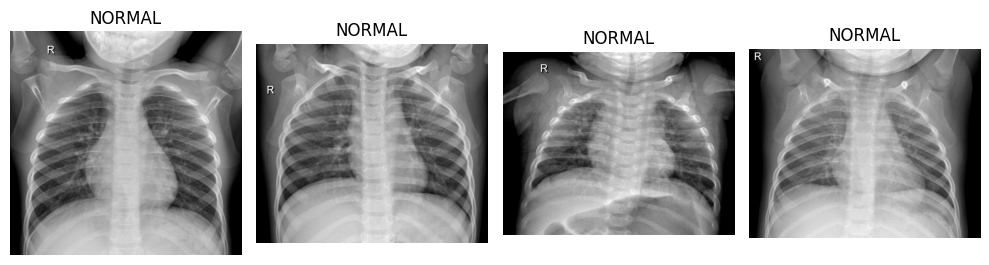

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import glob
import os

images = glob.glob(f"{data_path}/train/*/*.jpeg")

plt.figure(figsize=(10, 5))

for i, path in enumerate(images[:4]):
    img = Image.open(path)

    plt.subplot(1, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(os.path.basename(os.path.dirname(path)))
    plt.axis("off")

plt.tight_layout()
plt.show()

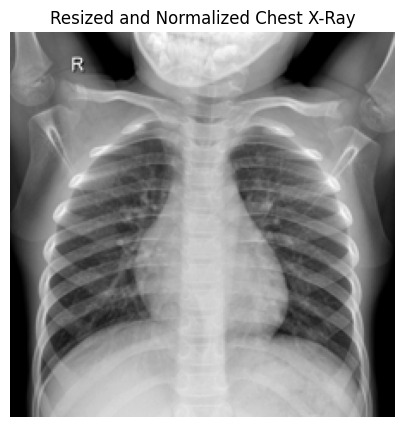

In [15]:
plt.figure(figsize=(5, 5))
plt.imshow(img_array, cmap="gray")
plt.title("Resized and Normalized Chest X-Ray")
plt.axis("off")
plt.show()

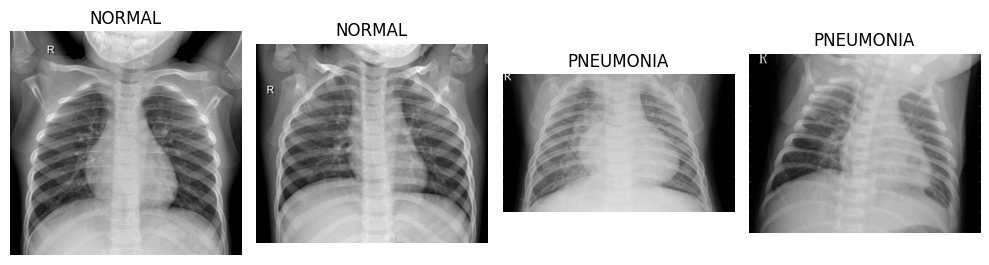

In [16]:
import glob
import os
import matplotlib.pyplot as plt
from PIL import Image

normal_images = glob.glob(f"{data_path}/train/NORMAL/*.jpeg")
pneumonia_images = glob.glob(f"{data_path}/train/PNEUMONIA/*.jpeg")

plt.figure(figsize=(10, 5))

# 2 Normal images
for i, path in enumerate(normal_images[:2]):
    img = Image.open(path)
    plt.subplot(1, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")

# 2 Pneumonia images
for i, path in enumerate(pneumonia_images[:2]):
    img = Image.open(path)
    plt.subplot(1, 4, i + 3)
    plt.imshow(img, cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.tight_layout()
plt.show()